In [1]:

import torch
from MST_Plus_Plus import MST_Plus_Plus
model = MST_Plus_Plus().cuda()
checkpoint = torch.load('/root/autodl-tmp/Undergraduate-Graduation-Design-Repository/MST-plus-plus/test_code/modelzoo/mst_plus_plus.pth')
model.load_state_dict(checkpoint['state_dict'], strict=True)


<All keys matched successfully>

In [5]:
import torch
checkpoint = torch.load('/root/autodl-tmp/Undergraduate-Graduation-Design-Repository/MST-plus-plus/test_code/modelzoo/net_300epoch.pth')
checkpoint['state_dict'].keys()

odict_keys(['conv_in.weight', 'body.0.embedding.weight', 'body.0.encoder_layers.0.0.blocks.0.0.rescale', 'body.0.encoder_layers.0.0.blocks.0.0.to_q.weight', 'body.0.encoder_layers.0.0.blocks.0.0.to_k.weight', 'body.0.encoder_layers.0.0.blocks.0.0.to_v.weight', 'body.0.encoder_layers.0.0.blocks.0.0.proj.weight', 'body.0.encoder_layers.0.0.blocks.0.0.proj.bias', 'body.0.encoder_layers.0.0.blocks.0.0.pos_emb.0.weight', 'body.0.encoder_layers.0.0.blocks.0.0.pos_emb.2.weight', 'body.0.encoder_layers.0.0.blocks.0.1.fn.net.0.weight', 'body.0.encoder_layers.0.0.blocks.0.1.fn.net.2.weight', 'body.0.encoder_layers.0.0.blocks.0.1.fn.net.4.weight', 'body.0.encoder_layers.0.0.blocks.0.1.norm.weight', 'body.0.encoder_layers.0.0.blocks.0.1.norm.bias', 'body.0.encoder_layers.0.1.weight', 'body.0.encoder_layers.1.0.blocks.0.0.rescale', 'body.0.encoder_layers.1.0.blocks.0.0.to_q.weight', 'body.0.encoder_layers.1.0.blocks.0.0.to_k.weight', 'body.0.encoder_layers.1.0.blocks.0.0.to_v.weight', 'body.0.encod

In [8]:
import h5py
import os
import numpy as np
from PIL import Image
data_root='/root/autodl-tmp/BiSRNet-Plus-Plus/datasets'
hyper_data_path = f'{data_root}/Train_Spec/'
with open(f'{data_root}/split_txt/train_list.txt', 'r') as fin:
    hyper_list = [line.replace('\n','.mat') for line in fin]
    hyper_list.sort()
    print(f'len(hyper) of ntire2022 dataset:{len(hyper_list)}')
    for i in range(5):
        hyper_path = hyper_data_path + hyper_list[i]
        with h5py.File(hyper_path, 'r') as mat:
                hyper =np.float32(np.array(mat['cube']))
                hyper = np.transpose(hyper, [0, 2, 1])
                for j in range(hyper.shape[0]):
                    hyper_spec=hyper[j,:,:]
                    single_channel = np.nan_to_num(hyper_spec)  # 处理NaN/Inf
                    min_val = np.min(single_channel)
                    max_val = np.max(single_channel)
                    if max_val != min_val:
                        img_normalized = (single_channel - min_val) / (max_val - min_val) * 255
                    else:
                        img_normalized = np.zeros_like(single_channel)
                    img_8bit = img_normalized.astype(np.uint8)
                    image=Image.fromarray(img_8bit)
                    image.save(os.path.join(f'{data_root}/train_hyper_spec/', f'{i}_{j}.jpg'))

len(hyper) of ntire2022 dataset:897


In [ ]:
import torch
from thop import profile
from architecture import model_generator
from fvcore.nn import FlopCountAnalysis
pretrained_model_path = '/root/autodl-tmp/BiSRNet-Plus-Plus/real/test_code/modelzoo/test_model.pth'  # 替换成你的预训练模型路径
# 1. 定义你的模型
model = model_generator(pretrained_model_path).cuda()  # 替换成你的网络

# 2. 构造一个输入（必须和你实际输入尺寸一致）
input = torch.randn(1, 3, 482, 512)  # batch=1, channel=3, H=482, W=512

flops=FlopCountAnalysis(model, input)

load model from /root/autodl-tmp/BiSRNet-Plus-Plus/real/test_code/modelzoo/test_model.pth
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_prelu() for <class 'torch.nn.modules.activation.PReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.normalization.LayerNorm'>.
[INFO] Register count_avgpool() for <class 'torch.nn.modules.pooling.AvgPool2d'>.


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [ ]:
import h5py
import scipy.io as sio
import numpy as np


mat_file_path='/root/autodl-tmp/BiSRNet-Plus-Plus/datasets/Train_Spec/ARAD_1K_0001.mat'
mat_data=h5py.File(mat_file_path, 'r')


In [3]:
mat_data.keys()

<KeysViewHDF5 ['bands', 'cube', 'norm_factor']>

In [4]:
mat_data['bands']

<HDF5 dataset "bands": shape (31, 1), type "<f8">

In [5]:
mat_data['cube']

<HDF5 dataset "cube": shape (31, 512, 482), type "<f4">

In [8]:
hyper_spec.shape

(512, 482)

In [11]:
import matplotlib.pyplot as plt

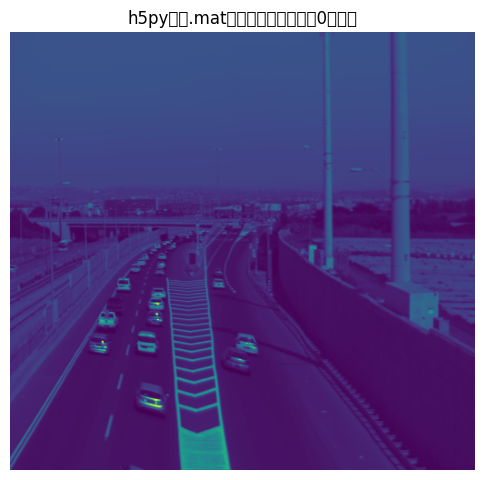

In [16]:
single_channel = np.nan_to_num(hyper[4,:,:])  # 处理NaN/Inf
min_val = np.min(single_channel)
max_val = np.max(single_channel)
if max_val != min_val:
    img_normalized = (single_channel - min_val) / (max_val - min_val) * 255
else:
    img_normalized = np.zeros_like(single_channel)
img_8bit = img_normalized.astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(img_8bit)
plt.axis('off')
plt.title('h5py读取.mat文件还原的图像（第0通道）')
plt.show()

In [3]:
import h5py
import torch
import cv2
import numpy as np
from PIL import Image
from architecture import model_generator
pretrained_model_path = '/root/autodl-tmp/BiSRNet-Plus-Plus/real/test_code/modelzoo/test_model.pth'
model = model_generator(pretrained_model_path).cuda()
model.eval()


load model from /root/autodl-tmp/BiSRNet-Plus-Plus/real/test_code/modelzoo/test_model.pth


BiSRNet(
  (conv_in): Conv2d(3, 31, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (fution): Conv2d(56, 31, kernel_size=(1, 1), stride=(1, 1))
  (body): Sequential(
    (0): BiSRNet_body(
      (embedding): BinaryConv2d(
        (move0): ReDistribution()
        (binary_activation): Spectral_Binary_Activation()
        (binary_conv): HardBinaryConv(31, 31, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (relu): RPReLU(
          (pr_bias0): LearnableBias()
          (pr_prelu): PReLU(num_parameters=31)
          (pr_bias1): LearnableBias()
        )
      )
      (encoder_layers): ModuleList(
        (0): ModuleList(
          (0): BiSRNet_Block(
            (blocks): ModuleList(
              (0): PreNorm(
                (fn): FeedForward(
                  (net): Sequential(
                    (0): BinaryConv2d_Fusion_Increase(
                      (biconv_1): BinaryConv2d(
                        (move0): ReDistribution()
                 

In [4]:
model

BiSRNet(
  (conv_in): Conv2d(3, 31, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (fution): Conv2d(56, 31, kernel_size=(1, 1), stride=(1, 1))
  (body): Sequential(
    (0): BiSRNet_body(
      (embedding): BinaryConv2d(
        (move0): ReDistribution()
        (binary_activation): Spectral_Binary_Activation()
        (binary_conv): HardBinaryConv(31, 31, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (relu): RPReLU(
          (pr_bias0): LearnableBias()
          (pr_prelu): PReLU(num_parameters=31)
          (pr_bias1): LearnableBias()
        )
      )
      (encoder_layers): ModuleList(
        (0): ModuleList(
          (0): BiSRNet_Block(
            (blocks): ModuleList(
              (0): PreNorm(
                (fn): FeedForward(
                  (net): Sequential(
                    (0): BinaryConv2d_Fusion_Increase(
                      (biconv_1): BinaryConv2d(
                        (move0): ReDistribution()
                 

In [ ]:

rgb = cv2.imread('/root/autodl-tmp/BiSRNet-Plus-Plus/datasets/Test_RGB/ARAD_1K_0951.jpg')
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
rgb = np.float32(rgb)
rgb = (rgb-rgb.min())/(rgb.max()-rgb.min())
rgb = np.transpose(rgb, [2, 0, 1]) 


In [19]:
torch_tensor=torch.from_numpy(rgb).cuda()

In [23]:
torch_tensor=torch_tensor.unsqueeze(dim=0)

In [24]:
torch_tensor.shape

torch.Size([1, 3, 482, 512])

In [25]:
hyper=model(torch_tensor)
print('hyper shape is ', hyper.shape)

hyper shape is  torch.Size([1, 31, 482, 512])


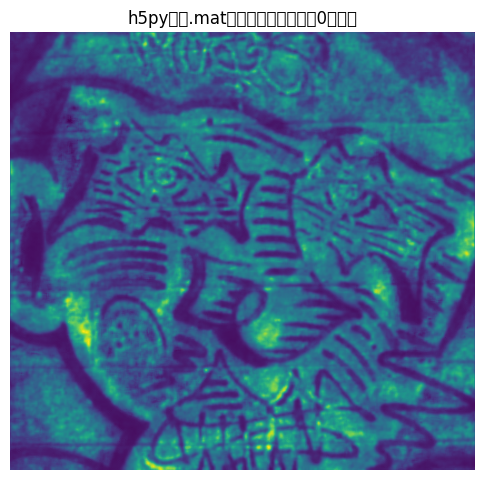

In [35]:
hyper_spec=hyper[0,0,:,:].cpu().detach().numpy()
hyper_spec.shape
single_channel = np.nan_to_num(hyper_spec)
import matplotlib.pyplot as plt

min_val = np.min(single_channel)
max_val = np.max(single_channel)
if max_val != min_val:
    img_normalized = (single_channel - min_val) / (max_val - min_val) * 255
else:
    img_normalized = np.zeros_like(single_channel)
img_8bit = img_normalized.astype(np.uint8)
plt.figure(figsize=(6, 6))
plt.imshow(img_8bit)
plt.axis('off')
plt.title('h5py读取.mat文件还原的图像（第0通道）')
plt.show()

In [6]:
# 读取txt文件并转换为长度为50的数组
with open('/root/autodl-tmp/BiSRNet-Plus-Plus/datasets/split_txt/valid_list.txt', 'r') as file:
    lines = file.readlines()

# 去除每行末尾的换行符并去掉.jpg后缀
array = [line.strip().replace('.jpg', '') for line in lines]

# 验证长度
if len(array) == 50:
    print("成功转换为长度为50的数组：")
    print(array)
else:
    print(f"数组长度为 {len(array)}，不是50。")

成功转换为长度为50的数组：
['ARAD_1K_0901', 'ARAD_1K_0902', 'ARAD_1K_0903', 'ARAD_1K_0904', 'ARAD_1K_0905', 'ARAD_1K_0906', 'ARAD_1K_0907', 'ARAD_1K_0908', 'ARAD_1K_0909', 'ARAD_1K_0910', 'ARAD_1K_0911', 'ARAD_1K_0912', 'ARAD_1K_0913', 'ARAD_1K_0914', 'ARAD_1K_0915', 'ARAD_1K_0916', 'ARAD_1K_0917', 'ARAD_1K_0918', 'ARAD_1K_0919', 'ARAD_1K_0920', 'ARAD_1K_0921', 'ARAD_1K_0922', 'ARAD_1K_0923', 'ARAD_1K_0924', 'ARAD_1K_0925', 'ARAD_1K_0926', 'ARAD_1K_0927', 'ARAD_1K_0928', 'ARAD_1K_0929', 'ARAD_1K_0930', 'ARAD_1K_0931', 'ARAD_1K_0932', 'ARAD_1K_0933', 'ARAD_1K_0934', 'ARAD_1K_0935', 'ARAD_1K_0936', 'ARAD_1K_0937', 'ARAD_1K_0938', 'ARAD_1K_0939', 'ARAD_1K_0940', 'ARAD_1K_0941', 'ARAD_1K_0942', 'ARAD_1K_0943', 'ARAD_1K_0944', 'ARAD_1K_0945', 'ARAD_1K_0946', 'ARAD_1K_0947', 'ARAD_1K_0948', 'ARAD_1K_0949', 'ARAD_1K_0950']


In [7]:
array[1]

'ARAD_1K_0902'

In [1]:
import hdf5storage
m=hdf5storage.loadmat('/root/autodl-tmp/exp/bisrnet_plus_plus/Valid_MAT/ARAD_1K_0901.mat')

In [2]:
m.keys()

dict_keys(['__header__', '__version__', '__globals__', 'result'])